In [1]:
#Import Required Libraries
import pandas as pd
import numpy as np

In [2]:
# Load the Dataset
df2=pd.read_csv("E:\\screening\\hospital_messy_data_30k.csv")

In [3]:
#Display the data
df2

,patient_id,patient_name,age,gender,city,admission_date,discharge_date,department,doctor_id,doctor_name,treatment_type,treatment_cost,insurance_coverage,billing_amount,payment_status,admission_type,length_of_stay
0,100000,Sunil,35.0,Female,hyderabad,2024/03/22,2024-03-23,Cardiology,243,Dr A,NaN,11556,NaN,NaN,Paid,Routine,NaN
1,100001,Anjali,60.0,male,NaN,2024-03-12,2024-03-16,Orthopedics,244,NaN,Therapy,147853,80.0,118282.4,Pending,emergency,NaN
2,100002,Sunil,-5.0,male,NaN,2024-02-18,2024-02-19,General,234,Dr A,NaN,99104,NaN,NaN,paid,NaN,15.0
3,100003,NaN,35.0,male,Hyderabad,2024-03-14,2024-03-18,Cardiology,224,Dr C,NaN,23233,0.0,18586.4,paid,Routine,6.0
4,100004,NaN,35.0,Female,hyderabad,27-01-2024,2024-02-02,General,217,Dr B,Therapy,23717,120.0,18973.6,Paid,Routine,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,129995,Sunil,35.0,female,Delhi,2024/01/28,2024-01-26,Orthopedics,246,Dr B,Consultation,50858,0.0,NaN,paid,emergency,NaN
29996,129996,Anjali,-5.0,female,Mumbai,10-01-2024,2024-01-09,Orthopedics,206,Dr C,Therapy,30489,NaN,30489.0,NaN,Emergency,NaN
29997,129997,NaN,45.0,female,hyderabad,2024/02/04,2024-02-08,Cardiology,216,Dr C,NaN,140859,80.0,112687.2,Paid,Emergency,11.0
29998,129998,NaN,35.0,Female,NaN,26-02-2024,2024-03-08,Orthopedics,208,Dr C,Consultation,32276,80.0,25820.8,pending,routine,8.0


In [4]:
#Checking Null Values
df2.isnull().sum()

patient_id                0
patient_name           5039
age                    5065
gender                    0
city                   8614
admission_date            0
discharge_date            0
department                0
doctor_id                 0
doctor_name            7600
treatment_type         7420
treatment_cost            0
insurance_coverage     8530
billing_amount         7385
payment_status         5942
admission_type         6012
length_of_stay        14947
dtype: int64

In [5]:
#Checking Data Types
df2.dtypes

patient_id              int64
patient_name           object
age                   float64
gender                 object
city                   object
admission_date         object
discharge_date         object
department             object
doctor_id               int64
doctor_name            object
treatment_type         object
treatment_cost          int64
insurance_coverage    float64
billing_amount        float64
payment_status         object
admission_type         object
length_of_stay        float64
dtype: object

In [81]:
df2.shape

(30000, 21)

In [6]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          30000 non-null  int64  
 1   patient_name        24961 non-null  object 
 2   age                 24935 non-null  float64
 3   gender              30000 non-null  object 
 4   city                21386 non-null  object 
 5   admission_date      30000 non-null  object 
 6   discharge_date      30000 non-null  object 
 7   department          30000 non-null  object 
 8   doctor_id           30000 non-null  int64  
 9   doctor_name         22400 non-null  object 
 10  treatment_type      22580 non-null  object 
 11  treatment_cost      30000 non-null  int64  
 12  insurance_coverage  21470 non-null  float64
 13  billing_amount      22615 non-null  float64
 14  payment_status      24058 non-null  object 
 15  admission_type      23988 non-null  object 
 16  leng

In [7]:
text_cols = ["patient_name", "gender", "city", "department", "doctor_name", "treatment_type", "payment_status","admission_type"]
for col in text_cols:
    df2[col] = df2[col].astype("string").str.strip().str.title()

In [8]:
df2.dtypes

patient_id                     int64
patient_name          string[python]
age                          float64
gender                string[python]
city                  string[python]
admission_date                object
discharge_date                object
department            string[python]
doctor_id                      int64
doctor_name           string[python]
treatment_type        string[python]
treatment_cost                 int64
insurance_coverage           float64
billing_amount               float64
payment_status        string[python]
admission_type        string[python]
length_of_stay               float64
dtype: object

In [9]:
for col in ["admission_date", "discharge_date"]:
    df2[col + "_raw"] = df2[col]

    try:
        df2[col + "_clean"] = pd.to_datetime(
            df2[col], errors="coerce", format="mixed"
        )
    except TypeError:
        df2[col + "_clean"] = pd.to_datetime(
            df2[col], errors="coerce", dayfirst=False
        )

        mask = df2[col + "_clean"].isna()
        df2.loc[mask, col + "_clean"] = pd.to_datetime(
            df2.loc[mask, col], errors="coerce", dayfirst=True
        )

In [10]:
df2["admission_date"] = df2["admission_date_clean"]
df2["discharge_date"] = df2["discharge_date_clean"]

In [11]:
df2.dtypes

patient_id                       int64
patient_name            string[python]
age                            float64
gender                  string[python]
city                    string[python]
admission_date          datetime64[ns]
discharge_date          datetime64[ns]
department              string[python]
doctor_id                        int64
doctor_name             string[python]
treatment_type          string[python]
treatment_cost                   int64
insurance_coverage             float64
billing_amount                 float64
payment_status          string[python]
admission_type          string[python]
length_of_stay                 float64
admission_date_raw              object
admission_date_clean    datetime64[ns]
discharge_date_raw              object
discharge_date_clean    datetime64[ns]
dtype: object

In [12]:
df2.drop(columns=[
    "admission_date_raw", "admission_date_clean",
    "discharge_date_raw", "discharge_date_clean"
], inplace=True)

In [13]:
df2.dtypes

patient_id                     int64
patient_name          string[python]
age                          float64
gender                string[python]
city                  string[python]
admission_date        datetime64[ns]
discharge_date        datetime64[ns]
department            string[python]
doctor_id                      int64
doctor_name           string[python]
treatment_type        string[python]
treatment_cost                 int64
insurance_coverage           float64
billing_amount               float64
payment_status        string[python]
admission_type        string[python]
length_of_stay               float64
dtype: object

In [14]:
df2.dtypes

patient_id                     int64
patient_name          string[python]
age                          float64
gender                string[python]
city                  string[python]
admission_date        datetime64[ns]
discharge_date        datetime64[ns]
department            string[python]
doctor_id                      int64
doctor_name           string[python]
treatment_type        string[python]
treatment_cost                 int64
insurance_coverage           float64
billing_amount               float64
payment_status        string[python]
admission_type        string[python]
length_of_stay               float64
dtype: object

# Data Cleaning

In [15]:
df2['patient_name'].fillna('Unknown', inplace=True)

C:\Users\DurgaBhavani\AppData\Local\Temp\ipykernel_8836\856231108.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['patient_name'].fillna('Unknown', inplace=True)


In [16]:
df2['patient_name'].unique()

<StringArray>
['Sunil', 'Anjali', 'Unknown', 'Ravi', 'Meena', 'Rahul']
Length: 6, dtype: string

In [17]:
df2

,patient_id,patient_name,age,gender,city,admission_date,discharge_date,department,doctor_id,doctor_name,treatment_type,treatment_cost,insurance_coverage,billing_amount,payment_status,admission_type,length_of_stay
0,100000,Sunil,35.0,Female,Hyderabad,2024-03-22,2024-03-23,Cardiology,243,Dr A,<NA>,11556,NaN,NaN,Paid,Routine,NaN
1,100001,Anjali,60.0,Male,<NA>,2024-03-12,2024-03-16,Orthopedics,244,<NA>,Therapy,147853,80.0,118282.4,Pending,Emergency,NaN
2,100002,Sunil,-5.0,Male,<NA>,2024-02-18,2024-02-19,General,234,Dr A,<NA>,99104,NaN,NaN,Paid,<NA>,15.0
3,100003,Unknown,35.0,Male,Hyderabad,2024-03-14,2024-03-18,Cardiology,224,Dr C,<NA>,23233,0.0,18586.4,Paid,Routine,6.0
4,100004,Unknown,35.0,Female,Hyderabad,2024-01-27,2024-02-02,General,217,Dr B,Therapy,23717,120.0,18973.6,Paid,Routine,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,129995,Sunil,35.0,Female,Delhi,2024-01-28,2024-01-26,Orthopedics,246,Dr B,Consultation,50858,0.0,NaN,Paid,Emergency,NaN
29996,129996,Anjali,-5.0,Female,Mumbai,2024-10-01,2024-01-09,Orthopedics,206,Dr C,Therapy,30489,NaN,30489.0,<NA>,Emergency,NaN
29997,129997,Unknown,45.0,Female,Hyderabad,2024-02-04,2024-02-08,Cardiology,216,Dr C,<NA>,140859,80.0,112687.2,Paid,Emergency,11.0
29998,129998,Unknown,35.0,Female,<NA>,2024-02-26,2024-03-08,Orthopedics,208,Dr C,Consultation,32276,80.0,25820.8,Pending,Routine,8.0


In [18]:
df2.loc[df2['patient_name'].isin(['Anjali','Meena']), 'gender'] = 'Female'

df2.loc[df2['patient_name'].isin(['Sunil','Ravi','Rahul']), 'gender'] = 'Male'

In [19]:
df2

,patient_id,patient_name,age,gender,city,admission_date,discharge_date,department,doctor_id,doctor_name,treatment_type,treatment_cost,insurance_coverage,billing_amount,payment_status,admission_type,length_of_stay
0,100000,Sunil,35.0,Male,Hyderabad,2024-03-22,2024-03-23,Cardiology,243,Dr A,<NA>,11556,NaN,NaN,Paid,Routine,NaN
1,100001,Anjali,60.0,Female,<NA>,2024-03-12,2024-03-16,Orthopedics,244,<NA>,Therapy,147853,80.0,118282.4,Pending,Emergency,NaN
2,100002,Sunil,-5.0,Male,<NA>,2024-02-18,2024-02-19,General,234,Dr A,<NA>,99104,NaN,NaN,Paid,<NA>,15.0
3,100003,Unknown,35.0,Male,Hyderabad,2024-03-14,2024-03-18,Cardiology,224,Dr C,<NA>,23233,0.0,18586.4,Paid,Routine,6.0
4,100004,Unknown,35.0,Female,Hyderabad,2024-01-27,2024-02-02,General,217,Dr B,Therapy,23717,120.0,18973.6,Paid,Routine,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,129995,Sunil,35.0,Male,Delhi,2024-01-28,2024-01-26,Orthopedics,246,Dr B,Consultation,50858,0.0,NaN,Paid,Emergency,NaN
29996,129996,Anjali,-5.0,Female,Mumbai,2024-10-01,2024-01-09,Orthopedics,206,Dr C,Therapy,30489,NaN,30489.0,<NA>,Emergency,NaN
29997,129997,Unknown,45.0,Female,Hyderabad,2024-02-04,2024-02-08,Cardiology,216,Dr C,<NA>,140859,80.0,112687.2,Paid,Emergency,11.0
29998,129998,Unknown,35.0,Female,<NA>,2024-02-26,2024-03-08,Orthopedics,208,Dr C,Consultation,32276,80.0,25820.8,Pending,Routine,8.0


In [20]:
df2['age'].unique()

array([35., 60., -5., 25., nan, 45.])

In [21]:
# Replace negative ages with NaN
df2['age'] = df2['age'].apply(lambda x: x if x >= 0 else np.nan)

In [22]:
df2['age'].isnull().sum()

np.int64(10014)

In [23]:
df2['age'].unique()

array([35., 60., nan, 25., 45.])

In [24]:
df2['department'].unique()

<StringArray>
['Cardiology', 'Orthopedics', 'General', 'Neurology', 'Pediatrics']
Length: 5, dtype: string

In [25]:
df2['age'] = df2['age'].fillna(
    df2.groupby(['gender', 'department'])['age'].transform('median')
)

In [26]:
df2['age'].isnull().sum()

np.int64(0)

In [27]:
df2['city'] = df2['city'].fillna(df2['city'].mode()[0])

In [28]:
df2['city'].isnull().sum()

np.int64(0)

In [29]:
df2['doctor_name'] = df2['doctor_name'].fillna('Unknown')

In [30]:
df2['treatment_type'].unique()

<StringArray>
[<NA>, 'Therapy', 'Consultation', 'Surgery']
Length: 4, dtype: string

In [31]:
df2.groupby('department')['treatment_type'].value_counts()

department   treatment_type
Cardiology   Therapy           1549
             Surgery           1449
             Consultation      1431
General      Surgery           1505
             Therapy           1486
             Consultation      1453
Neurology    Therapy           1549
             Consultation      1540
             Surgery           1472
Orthopedics  Surgery           1571
             Therapy           1535
             Consultation      1487
Pediatrics   Surgery           1554
             Consultation      1520
             Therapy           1479
Name: count, dtype: int64

In [32]:
df2['treatment_type'] = df2['treatment_type'].fillna(
    df2.groupby('department')['treatment_type']
       .transform(lambda x: x.mode()[0] if not x.mode().empty else None)
)

In [33]:
df2.loc[(df2['insurance_coverage'] < 0) | (df2['insurance_coverage'] > 100), 'insurance_coverage'] = None

In [34]:
df2['insurance_coverage'].isnull().sum()

np.int64(12768)

In [35]:
df2['insurance_coverage'] = df2['insurance_coverage'].fillna(
    df2.groupby(['department', 'treatment_type'])['insurance_coverage']
       .transform('median')
)

In [36]:
df2['insurance_coverage'].isnull().sum()

np.int64(0)

In [37]:
df2['billing_amount'] = df2['billing_amount'].fillna(
    df2['treatment_cost'] * (df2['insurance_coverage'] / 100)
)

In [38]:
df2

,patient_id,patient_name,age,gender,city,admission_date,discharge_date,department,doctor_id,doctor_name,treatment_type,treatment_cost,insurance_coverage,billing_amount,payment_status,admission_type,length_of_stay
0,100000,Sunil,35.0,Male,Hyderabad,2024-03-22,2024-03-23,Cardiology,243,Dr A,Therapy,11556,50.0,5778.0,Paid,Routine,NaN
1,100001,Anjali,60.0,Female,Hyderabad,2024-03-12,2024-03-16,Orthopedics,244,Unknown,Therapy,147853,80.0,118282.4,Pending,Emergency,NaN
2,100002,Sunil,45.0,Male,Hyderabad,2024-02-18,2024-02-19,General,234,Dr A,Surgery,99104,50.0,49552.0,Paid,<NA>,15.0
3,100003,Unknown,35.0,Male,Hyderabad,2024-03-14,2024-03-18,Cardiology,224,Dr C,Therapy,23233,0.0,18586.4,Paid,Routine,6.0
4,100004,Unknown,35.0,Female,Hyderabad,2024-01-27,2024-02-02,General,217,Dr B,Therapy,23717,20.0,18973.6,Paid,Routine,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,129995,Sunil,35.0,Male,Delhi,2024-01-28,2024-01-26,Orthopedics,246,Dr B,Consultation,50858,0.0,0.0,Paid,Emergency,NaN
29996,129996,Anjali,45.0,Female,Mumbai,2024-10-01,2024-01-09,Orthopedics,206,Dr C,Therapy,30489,50.0,30489.0,<NA>,Emergency,NaN
29997,129997,Unknown,45.0,Female,Hyderabad,2024-02-04,2024-02-08,Cardiology,216,Dr C,Therapy,140859,80.0,112687.2,Paid,Emergency,11.0
29998,129998,Unknown,35.0,Female,Hyderabad,2024-02-26,2024-03-08,Orthopedics,208,Dr C,Consultation,32276,80.0,25820.8,Pending,Routine,8.0


In [39]:
df2.isnull().sum()

patient_id                0
patient_name              0
age                       0
gender                    0
city                      0
admission_date            0
discharge_date            0
department                0
doctor_id                 0
doctor_name               0
treatment_type            0
treatment_cost            0
insurance_coverage        0
billing_amount            0
payment_status         5942
admission_type         6012
length_of_stay        14947
dtype: int64

In [40]:
df2['billing_amount'].min(), df2['billing_amount'].max()

(0.0, 149992.0)

In [41]:
df2.loc[df2['payment_status'].isna(), 'payment_status'] = np.where(
    df2.loc[df2['payment_status'].isna(), 'billing_amount'] >= 100000,
    'Pending',
    'Paid'
)

In [42]:
df2.isnull().sum()

patient_id                0
patient_name              0
age                       0
gender                    0
city                      0
admission_date            0
discharge_date            0
department                0
doctor_id                 0
doctor_name               0
treatment_type            0
treatment_cost            0
insurance_coverage        0
billing_amount            0
payment_status            0
admission_type         6012
length_of_stay        14947
dtype: int64

In [43]:
df2['admission_type'] = df2['admission_type'].fillna(
    df2.groupby('department')['admission_type']
       .transform(lambda x: x.mode()[0] if not x.mode().empty else None)
)

In [44]:
df2.isnull().sum()

patient_id                0
patient_name              0
age                       0
gender                    0
city                      0
admission_date            0
discharge_date            0
department                0
doctor_id                 0
doctor_name               0
treatment_type            0
treatment_cost            0
insurance_coverage        0
billing_amount            0
payment_status            0
admission_type            0
length_of_stay        14947
dtype: int64

In [73]:
# Step 1: Calculate
df2['length_of_stay'] = (df2['discharge_date'] - df2['admission_date']).dt.days

# Step 2: Replace invalid values with NaN
df2['length_of_stay'] = df2['length_of_stay'].mask(df2['length_of_stay'] < 0, np.nan)

# Step 3: Fill NaN with 1
df2['length_of_stay'] = df2['length_of_stay'].fillna(1)

In [74]:
df2.isnull().sum()

patient_id            0
patient_name          0
age                   0
gender                0
city                  0
admission_date        0
discharge_date        0
department            0
doctor_id             0
doctor_name           0
treatment_type        0
treatment_cost        0
insurance_coverage    0
billing_amount        0
payment_status        0
admission_type        0
length_of_stay        0
insurance_amount      0
hospital_revenue      0
admission_month       0
admission_year        0
dtype: int64

In [75]:
df2

,patient_id,patient_name,age,gender,city,admission_date,discharge_date,department,doctor_id,doctor_name,...,treatment_cost,insurance_coverage,billing_amount,payment_status,admission_type,length_of_stay,insurance_amount,hospital_revenue,admission_month,admission_year
0,100000,Sunil,35.0,Male,Hyderabad,2024-03-22,2024-03-23,Cardiology,243,Dr A,...,11556,50.0,5778.0,Paid,Routine,1.0,5778.0,5778.0,3,2024
1,100001,Anjali,60.0,Female,Hyderabad,2024-03-12,2024-03-16,Orthopedics,244,Unknown,...,147853,80.0,118282.4,Pending,Emergency,4.0,118282.4,29570.6,3,2024
2,100002,Sunil,45.0,Male,Hyderabad,2024-02-18,2024-02-19,General,234,Dr A,...,99104,50.0,49552.0,Paid,Emergency,1.0,49552.0,49552.0,2,2024
3,100003,Unknown,35.0,Male,Hyderabad,2024-03-14,2024-03-18,Cardiology,224,Dr C,...,23233,0.0,18586.4,Paid,Routine,4.0,0.0,23233.0,3,2024
4,100004,Unknown,35.0,Female,Hyderabad,2024-01-27,2024-02-02,General,217,Dr B,...,23717,20.0,18973.6,Paid,Routine,6.0,4743.4,18973.6,1,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,129995,Sunil,35.0,Male,Delhi,2024-01-28,2024-01-26,Orthopedics,246,Dr B,...,50858,0.0,0.0,Paid,Emergency,1.0,0.0,50858.0,1,2024
29996,129996,Anjali,45.0,Female,Mumbai,2024-10-01,2024-01-09,Orthopedics,206,Dr C,...,30489,50.0,30489.0,Paid,Emergency,1.0,15244.5,15244.5,10,2024
29997,129997,Unknown,45.0,Female,Hyderabad,2024-02-04,2024-02-08,Cardiology,216,Dr C,...,140859,80.0,112687.2,Paid,Emergency,4.0,112687.2,28171.8,2,2024
29998,129998,Unknown,35.0,Female,Hyderabad,2024-02-26,2024-03-08,Orthopedics,208,Dr C,...,32276,80.0,25820.8,Pending,Routine,11.0,25820.8,6455.2,2,2024


# Feature Engineering

In [82]:
#Length of stay

# Step 1: Calculate
df2['length_of_stay'] = (df2['discharge_date'] - df2['admission_date']).dt.days

# Step 2: Replace invalid values with NaN
df2['length_of_stay'] = df2['length_of_stay'].mask(df2['length_of_stay'] < 0, np.nan)

# Step 3: Fill NaN with 1
df2['length_of_stay'] = df2['length_of_stay'].fillna(1)

In [83]:
df2['length_of_stay']

0         1.0
1         4.0
2         1.0
3         4.0
4         6.0
         ... 
29995     1.0
29996     1.0
29997     4.0
29998    11.0
29999     6.0
Name: length_of_stay, Length: 30000, dtype: float64

In [50]:
# Insurance amount
df2['insurance_amount'] = df2['treatment_cost'] * (df2['insurance_coverage'] / 100)

In [56]:
df2['insurance_amount']

0          5778.0
1        118282.4
2         49552.0
3             0.0
4          4743.4
           ...   
29995         0.0
29996     15244.5
29997    112687.2
29998     25820.8
29999      5496.8
Name: insurance_amount, Length: 30000, dtype: float64

In [51]:
# Hospital_revenue
df2['hospital_revenue'] = df2['treatment_cost'] - df2['insurance_amount']

In [57]:
df2['hospital_revenue']

0         5778.0
1        29570.6
2        49552.0
3        23233.0
4        18973.6
          ...   
29995    50858.0
29996    15244.5
29997    28171.8
29998     6455.2
29999     1374.2
Name: hospital_revenue, Length: 30000, dtype: float64

In [52]:
# Admission_Month and Admission Year
df2['admission_month'] = df2['admission_date'].dt.month
df2['admission_year'] = df2['admission_date'].dt.year

In [53]:
df2['admission_month']

0         3
1         3
2         2
3         3
4         1
         ..
29995     1
29996    10
29997     2
29998     2
29999     1
Name: admission_month, Length: 30000, dtype: int32

In [54]:
df2['admission_year']

0        2024
1        2024
2        2024
3        2024
4        2024
         ... 
29995    2024
29996    2024
29997    2024
29998    2024
29999    2024
Name: admission_year, Length: 30000, dtype: int32

# Data Analysis

In [59]:
# Revenue by department
df2.groupby('department')['hospital_revenue'].sum().sort_values(ascending=False)

department
Pediatrics     3.253711e+08
Neurology      3.126914e+08
General        2.956818e+08
Orthopedics    2.778084e+08
Cardiology     2.684961e+08
Name: hospital_revenue, dtype: float64

In [61]:
# Average Stay by Department
df2.groupby('department')['length_of_stay'].mean().sort_values(ascending=False)

department
Neurology      -9.704436
Cardiology    -10.472868
Orthopedics   -10.860646
Pediatrics    -11.076221
General       -12.109516
Name: length_of_stay, dtype: float64

In [76]:
# Doctor Performance
df2.groupby('doctor_name')['hospital_revenue'].sum().sort_values(ascending=False)

doctor_name
Dr A       3.804626e+08
Unknown    3.749222e+08
Dr C       3.672386e+08
Dr B       3.574254e+08
Name: hospital_revenue, dtype: float64

In [67]:
# Patient Distribution
df2['department'].value_counts()

department
Orthopedics    6035
Pediatrics     6022
Neurology      6019
General        5990
Cardiology     5934
Name: count, dtype: Int64

In [77]:
# Admission trends
df2.groupby('admission_month')['patient_id'].count()

admission_month
1     9170
2     8778
3     9095
4      328
5      338
6      320
7      316
8      321
9      330
10     331
11     336
12     337
Name: patient_id, dtype: int64

In [78]:
df2.to_csv("cleaned_hospital_data.csv", index=False)

In [80]:
df2.to_csv(r"E:\\screening\\cleaned_hospital_data.csv", index=False)

In [79]:
import os
os.getcwd()

'C:\\Users\\DurgaBhavani'

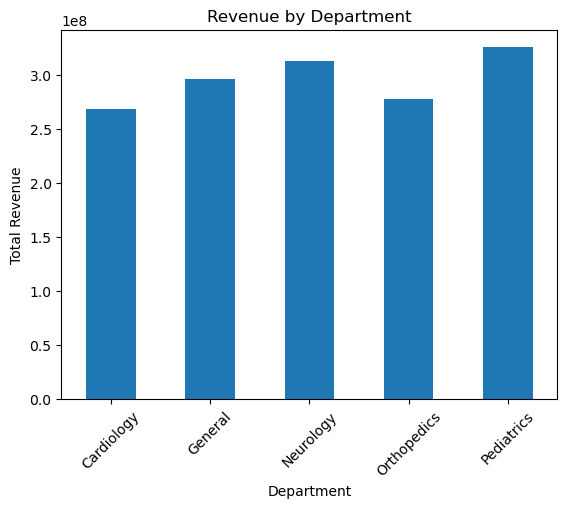

In [85]:
import matplotlib.pyplot as plt

rev_dept = df2.groupby('department')['hospital_revenue'].sum()

plt.figure()
rev_dept.plot(kind='bar')
plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

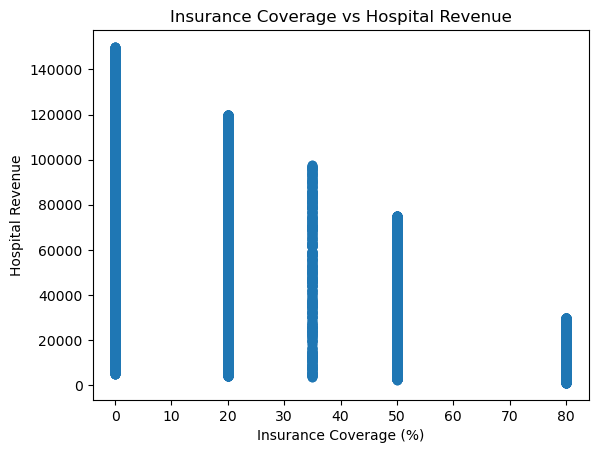

In [88]:
plt.figure()
plt.scatter(df2['insurance_coverage'], df2['hospital_revenue'])
plt.title("Insurance Coverage vs Hospital Revenue")
plt.xlabel("Insurance Coverage (%)")
plt.ylabel("Hospital Revenue")
plt.show()

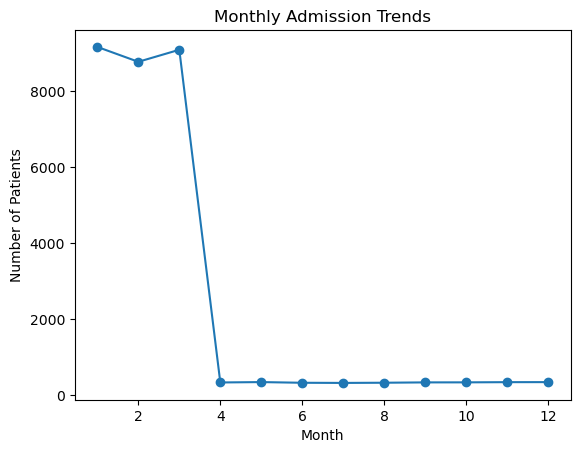

In [89]:
admissions = df2.groupby('admission_month')['patient_id'].count()

plt.figure()
admissions.plot(kind='line', marker='o')
plt.title("Monthly Admission Trends")
plt.xlabel("Month")
plt.ylabel("Number of Patients")
plt.show()

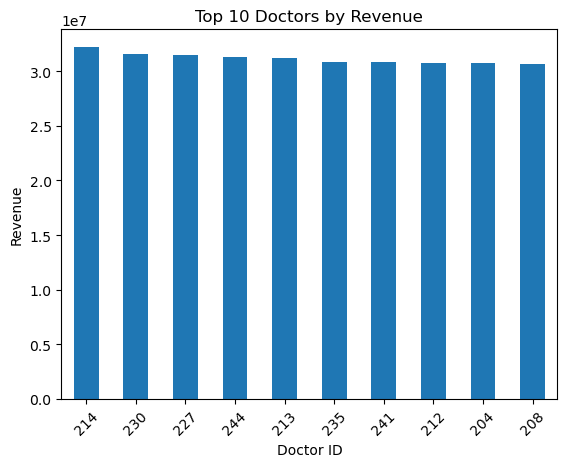

In [90]:
doc_perf = df2.groupby('doctor_id')['hospital_revenue'].sum().sort_values(ascending=False).head(10)

plt.figure()
doc_perf.plot(kind='bar')
plt.title("Top 10 Doctors by Revenue")
plt.xlabel("Doctor ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()